# Pixelized Source Reconstruction Demo

This notebook simulates a lensed image from an analytic Sersic source, then fits it with a
Voronoi pixelization using a Delaunay-based mapping and linear inversion.

Note: The Delaunay/Voronoi topology is computed on the host via SciPy and must be rebuilt
if the traced source-plane grid or seeds change.


In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "..")

import jax_lens as jl
from jax_lens.lens.tracer import TracerConfig, PlaneConfig, traced_grid_list, tracer_image
from jax_lens.fitting.imaging import convolve_image, log_likelihood
from jax_lens.pixelization import (
    PixelizationConfig,
    build_pixelization_cache,
    pixelized_source_reconstruction,
)


In [3]:
# Build image-plane grid
n = 64
y = jnp.linspace(-2.5, 2.5, n)
x = jnp.linspace(-2.5, 2.5, n)
yy, xx = jnp.meshgrid(y, x, indexing="ij")
grid = jnp.stack([yy, xx], axis=-1).reshape(-1, 2)

# Lens + source parameters
lens_mass = {
    "centre": jnp.array([0.0, 0.0]),
    "einstein_radius": 1.2,
    "axis_ratio": 0.8,
    "angle": 0.4,
}
source_light = {
    "centre": jnp.array([0.1, 0.05]),
    "intensity": 1.0,
    "effective_radius": 0.25,
    "sersic_index": 1.0,
    "axis_ratio": 0.9,
    "angle": 0.2,
}

lens_plane = PlaneConfig(
    redshift=0.5,
    light_profile_types=(),
    mass_profile_types=("sie",),
)
source_plane = PlaneConfig(
    redshift=1.0,
    light_profile_types=("sersic",),
    mass_profile_types=(),
)
config = TracerConfig(planes=(lens_plane, source_plane))

params = {
    "planes": [
        {"mass": [lens_mass], "light": []},
        {"mass": [], "light": [source_light]},
    ]
}

# Simulate lensed image
model = tracer_image(grid, config, params).reshape(n, n)

def gaussian_psf(size=9, sigma=1.0):
    ax = jnp.arange(size) - size // 2
    yy, xx = jnp.meshgrid(ax, ax, indexing="ij")
    kernel = jnp.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    return kernel / jnp.sum(kernel)

psf = gaussian_psf(size=9, sigma=1.0)
blurred = convolve_image(model, psf)

noise_sigma = 0.05
rng = np.random.default_rng(42)
noise = noise_sigma * rng.standard_normal(size=(n, n))
data = np.array(blurred) + noise
noise_map = np.full((n, n), noise_sigma)

data_flat = jnp.asarray(data).reshape(-1)
noise_flat = jnp.asarray(noise_map).reshape(-1)


ERROR:2026-01-13 11:48:46,756:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN


In [5]:
# Build a Voronoi/Delaunay pixelization in the source plane
traced = traced_grid_list(grid, config, params)[-1]
t = np.array(traced)
ymin, ymax = t[:, 0].min(), t[:, 0].max()
xmin, xmax = t[:, 1].min(), t[:, 1].max()

n_side = 25
ys = np.linspace(ymin + 0.05, ymax - 0.05, n_side)
xs = np.linspace(xmin + 0.05, xmax - 0.05, n_side)
yy, xx = np.meshgrid(ys, xs, indexing="ij")
seeds = np.stack([yy.ravel(), xx.ravel()], axis=-1)
seeds_jnp = jnp.asarray(seeds)

cache = build_pixelization_cache(seeds, t)
pix_cfg = PixelizationConfig(regularization_weight=1.0, solver="dense")


In [6]:
# Pixelized source reconstruction (includes PSF in the inversion)
source_model, source_values = pixelized_source_reconstruction(
    points=traced,
    seeds=seeds_jnp,
    cache=cache,
    data=data_flat,
    noise_map=noise_flat,
    regularization_weight=pix_cfg.regularization_weight,
    solver=pix_cfg.solver,
    psf=psf,
    image_shape=(n, n),
)

model_recon = source_model.reshape(n, n)
log_like = log_likelihood(data_flat, source_model, noise_flat)
print(f"Log-likelihood (pixelized): {float(log_like):.2f}")


Log-likelihood (pixelized): 5569.44


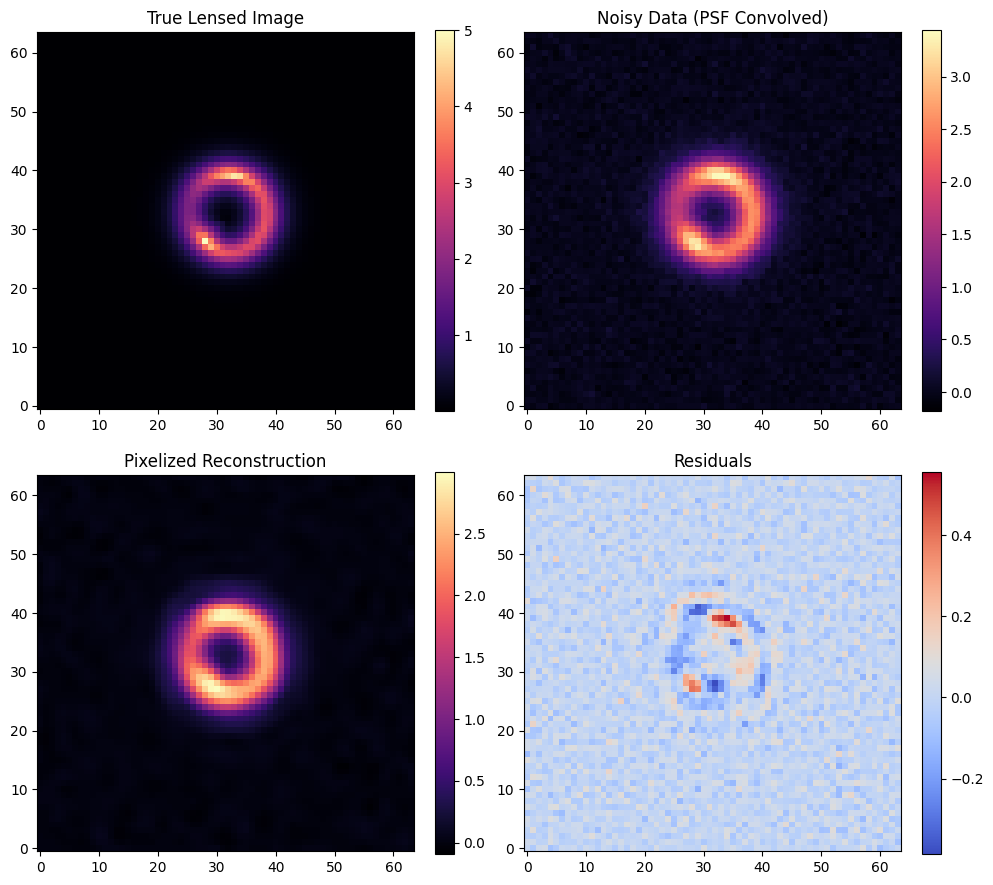

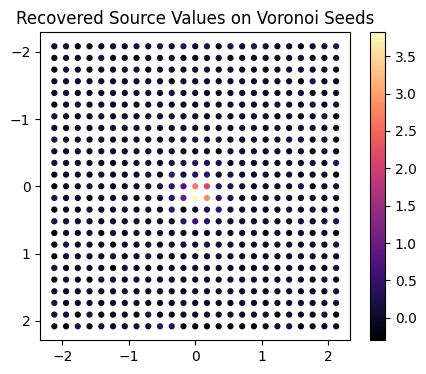

In [7]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

im0 = axes[0].imshow(model, origin="lower", cmap="magma")
axes[0].set_title("True Lensed Image")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(data, origin="lower", cmap="magma")
axes[1].set_title("Noisy Data (PSF Convolved)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(model_recon, origin="lower", cmap="magma")
axes[2].set_title("Pixelized Reconstruction")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(data - np.array(model_recon), origin="lower", cmap="coolwarm")
axes[3].set_title("Residuals")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.scatter(seeds[:, 1], seeds[:, 0], c=np.array(source_values), s=12, cmap="magma")
plt.gca().invert_yaxis()
plt.title("Recovered Source Values on Voronoi Seeds")
plt.colorbar()
plt.show()
